# Visualisation fusionnee des resultats RT-Diffusion

Notebook unique pour remplacer les trois variantes proches:

- baseline SGM/DDPM sur images `.pt`;
- cascade WSGM complete avec coarse genere;
- cascade WSGM avec coarse de reference.

Les fonctions communes sont dans `analyse_reslutat/libs/visualization.py`.

In [1]:
from pathlib import Path
import os
import sys

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

# Rend l'import robuste que Jupyter soit lance depuis la racine du projet ou depuis analyse_reslutat/.
start = Path.cwd().resolve()
for candidate in (start, *start.parents):
    if (candidate / "analyse_reslutat" / "libs").is_dir():
        sys.path.insert(0, str(candidate / "analyse_reslutat"))
        break
    if candidate.name == "analyse_reslutat" and (candidate / "libs").is_dir():
        sys.path.insert(0, str(candidate))
        break
else:
    raise RuntimeError("Impossible de trouver analyse_reslutat/libs depuis le dossier courant.")

import matplotlib.pyplot as plt
import numpy as np
import torch

from libs.visualization import (
    apply_report_style,
    compare_result_metrics,
    compute_baseline_phyfid_scores,
    compute_cascade_stage_phyfid,
    configure_project_paths,
    default_baseline_config,
    default_cascade_configs,
    line_metric,
    load_baseline_data,
    load_cascade_data,
    normalize_01,
    plot_density_joyplots,
    plot_energy_joyplots,
    plot_loss_curve,
    plot_loss_curves,
    plot_single_channel_comparison,
    plot_spectral_energy,
    plot_wavelet_level_comparison,
    plot_wavelet_report_figures,
    print_dataset_summaries,
    print_phyfid_scores,
    print_phyfid_stage_table,
    print_result_metrics,
    save_figure,
    show_grid,
    squeeze_channel,
    transformation_fluctuation_energy_spectrum,
)

project_root = configure_project_paths()
apply_report_style()
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
REPORT_FIGURE_DIR = project_root / "doc" / "BDRPReportTemplate" / "figures" / "ch5"

print("PROJECT_ROOT =", project_root)
print("DEVICE =", DEVICE)

PROJECT_ROOT = /home/chapuissamuel/Documents/code/RT-Diffusion
DEVICE = cpu


## Parametres globaux

Les cellules suivantes ne recalculent pas les generations; elles chargent les tenseurs deja sauvegardes.

In [2]:
CMAP = "gray"
SEED = 0
N_GRID = 16

RUN_PHYFID = True          # couteux: charge les encodeurs PhyFID
RUN_INCEPTION_FID = False  # optionnel, plus lourd et rarement utile ici
SAVE_REPORT_FIGURES = True

BASELINE_JOYPLOT_COLORS = {"generated": "#d62728", "noise": "black", "MNIST": "black"}
BASELINE_JOYPLOT_TITLE_LABELS = {"generated": "Generated", "noise": "Noise", "MNIST": "MNIST"}
BASELINE_JOYPLOT_LEGEND_LABELS = {"generated": "SGM", "noise": "Noise", "MNIST": "MNIST"}

CASCADE_REPORT_LABELS = {
    "generated_coarse": "WSGM: generated coarse",
    "reference_coarse": "WSGM: reference coarse",
}
CASCADE_JOYPLOT_LABELS = {
    "generated_coarse": "WSGM with generated coarse",
    "reference_coarse": "WSGM with reference",
}
CASCADE_JOYPLOT_COLORS = {
    "generated_coarse": "#08519c",
    "reference_coarse": "#6baed6",
}

baseline_cfg = default_baseline_config(project_root)
cascade_cfgs = default_cascade_configs(project_root)

# Choisir: "generated_coarse" ou "reference_coarse".
CASCADE_KEY = "generated_coarse"
cascade_cfg = cascade_cfgs[CASCADE_KEY]
cascade_report_label = CASCADE_REPORT_LABELS[CASCADE_KEY]
cascade_joyplot_label = CASCADE_JOYPLOT_LABELS[CASCADE_KEY]
cascade_joyplot_color = CASCADE_JOYPLOT_COLORS[CASCADE_KEY]

print("Cascade selectionnee:", CASCADE_KEY, "->", cascade_cfg.name)
print("Sorties:", cascade_cfg.output_dir)
print("Logs:", cascade_cfg.csv_dir)

Cascade selectionnee: generated_coarse -> WSGM cascade complete - coarse genere
Sorties: /home/chapuissamuel/Documents/code/RT-Diffusion/outputs/generated/cascade_sgm_hcirc_blurpool_eps00001
Logs: /home/chapuissamuel/Documents/code/RT-Diffusion/outputs/logs/cascade_sgm_hcirc_blurpool_eps00001


## Baseline SGM / DDPM

In [3]:
baseline = load_baseline_data(baseline_cfg)
print_dataset_summaries(baseline)

train                        shape=(49360, 64, 64)    dtype=torch.float32 min=   0.000 max= 255.000 mean= 126.475 std= 120.893
test                         shape=(11420, 64, 64)    dtype=torch.float32 min=   0.000 max= 255.000 mean= 126.438 std= 120.968
validation                   shape=(4500, 64, 64)     dtype=torch.float32 min=   0.000 max= 255.000 mean= 126.446 std= 123.174
generated                    shape=(2048, 1, 64, 64)  dtype=torch.float32 min=   0.000 max= 255.000 mean= 126.664 std= 119.842
noise                        shape=(2048, 1, 64, 64)  dtype=torch.float32 min=   0.000 max= 255.000 mean= 121.420 std=  91.463
MNIST                        shape=(54000, 64, 64)    dtype=torch.float32 min=   0.000 max= 255.000 mean=  33.324 std=  73.723


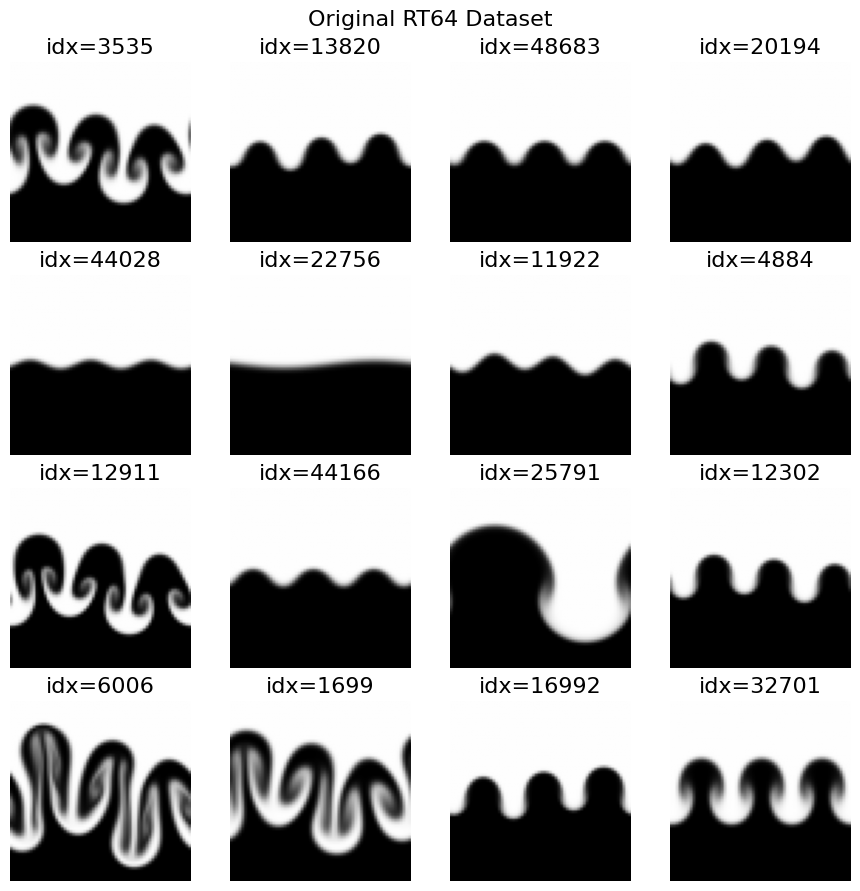

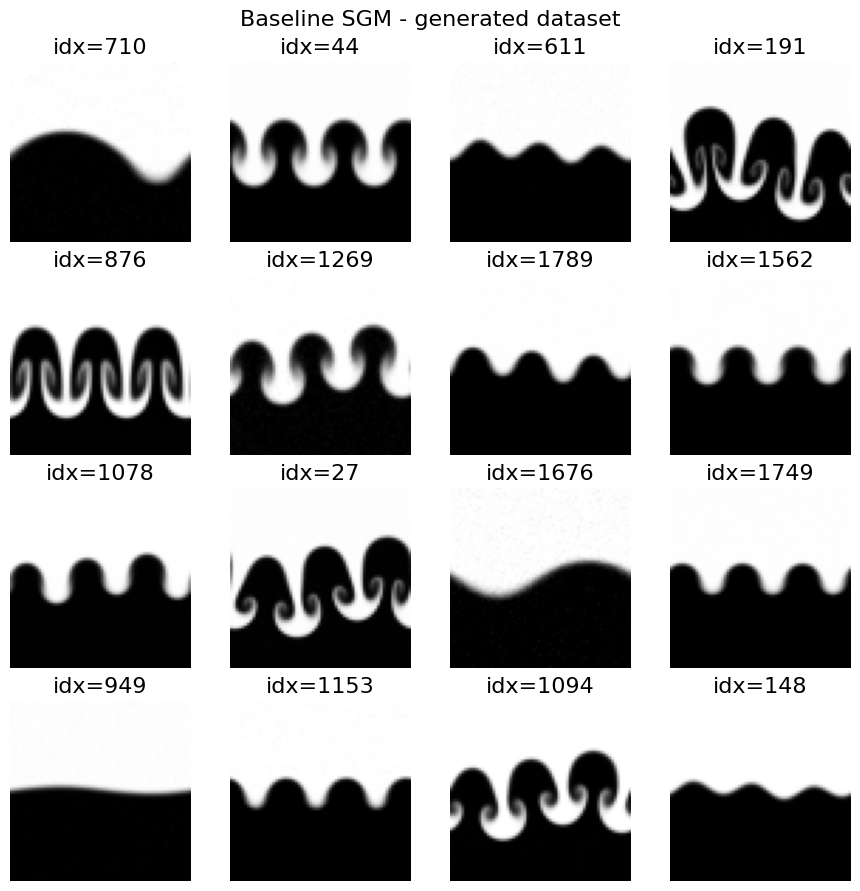

(<Figure size 880x880 with 16 Axes>,
 array([ 710,   44,  611,  191,  876, 1269, 1789, 1562, 1078,   27, 1676,
        1749,  949, 1153, 1094,  148]))

In [4]:
show_grid(
    baseline["train"],
    n=N_GRID,
    cols=4,
    cmap=CMAP,
    seed=20,
    title="Original RT64 Dataset",
)
show_grid(
    baseline["generated"],
    n=N_GRID,
    cols=4,
    cmap=CMAP,
    seed=16,
    title="Baseline SGM - generated dataset",
)

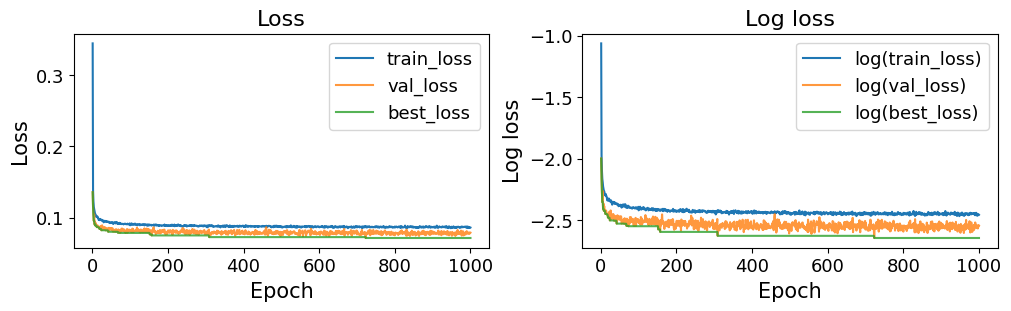

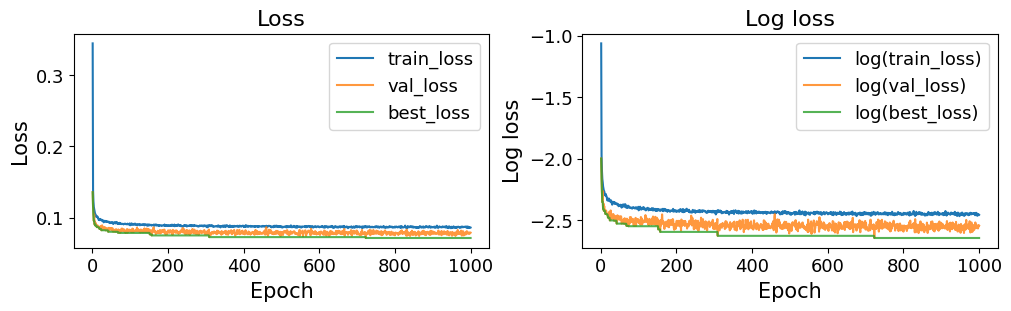

In [5]:
plot_loss_curve(baseline_cfg.loss_csv)

In [6]:
if RUN_PHYFID:
    n_images, phyfid_scores = compute_baseline_phyfid_scores(
        baseline,
        baseline_cfg.phyfid_encoder,
        max_images=1000,
        batch_size=baseline_cfg.phyfid_batch_size,
        device=DEVICE,
    )
    print_phyfid_scores(n_images, phyfid_scores)

PhyFID comparison on 1000 images
val vs val                 0.6672
val vs train               0.2221
val vs generated           0.5807
val vs noise               5.3714
val vs MNIST               4.3910


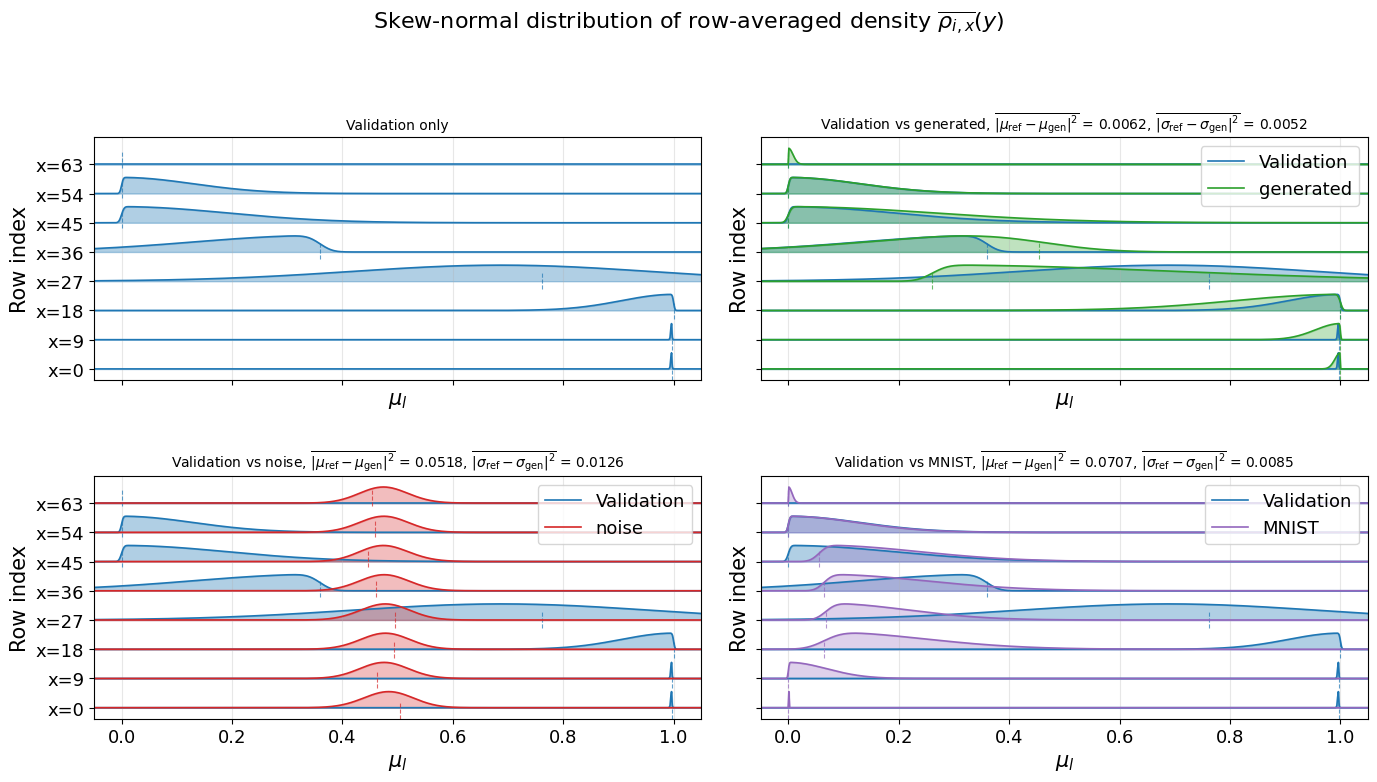

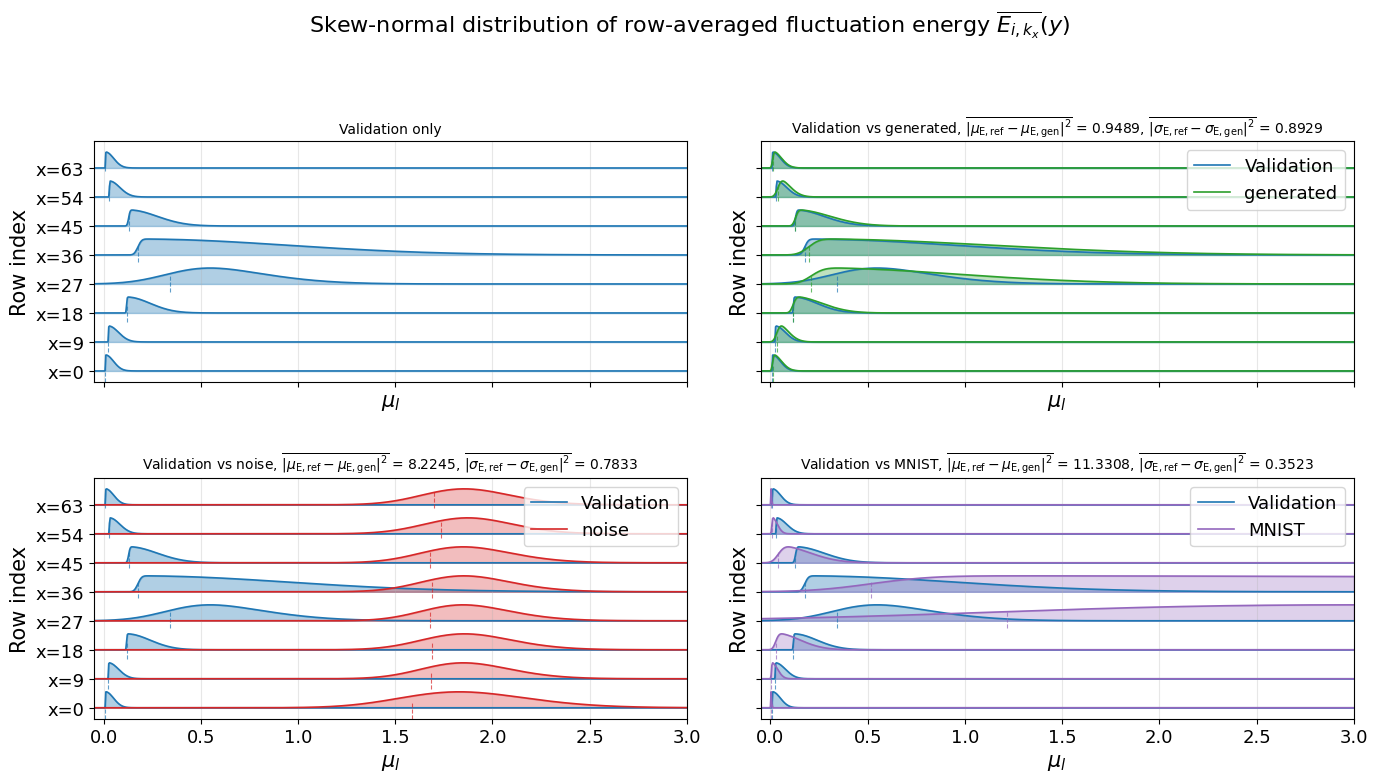

In [7]:
val_stats = normalize_01(baseline["validation"])
baseline_stats = {
    "generated": normalize_01(baseline["generated"]),
    "noise": normalize_01(baseline["noise"]),
    "MNIST": normalize_01(baseline["MNIST"]),
}

fig, density_stats = plot_density_joyplots(
    val_stats,
    baseline_stats,
    n_curves=8,
    colors=BASELINE_JOYPLOT_COLORS,
    title_labels=BASELINE_JOYPLOT_TITLE_LABELS,
    legend_labels=BASELINE_JOYPLOT_LEGEND_LABELS,
    save_path=project_root / "doc" / "BDRPReportTemplate" / "figures" / "ch4" / "skewnorm_joyplot.png" if SAVE_REPORT_FIGURES else None,
)
fig, energy_stats = plot_energy_joyplots(
    val_stats,
    baseline_stats,
    n_curves=8,
    colors=BASELINE_JOYPLOT_COLORS,
    title_labels=BASELINE_JOYPLOT_TITLE_LABELS,
    legend_labels=BASELINE_JOYPLOT_LEGEND_LABELS,
    save_path=project_root / "doc" / "BDRPReportTemplate" / "figures" / "ch4" / "skewnorm_joyplot_energy_spectrum.png" if SAVE_REPORT_FIGURES else None,
)

/tmp/ipykernel_8570/1944558796.py:1: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  fluctuation_val = np.abs(val_stats - val_stats.mean())


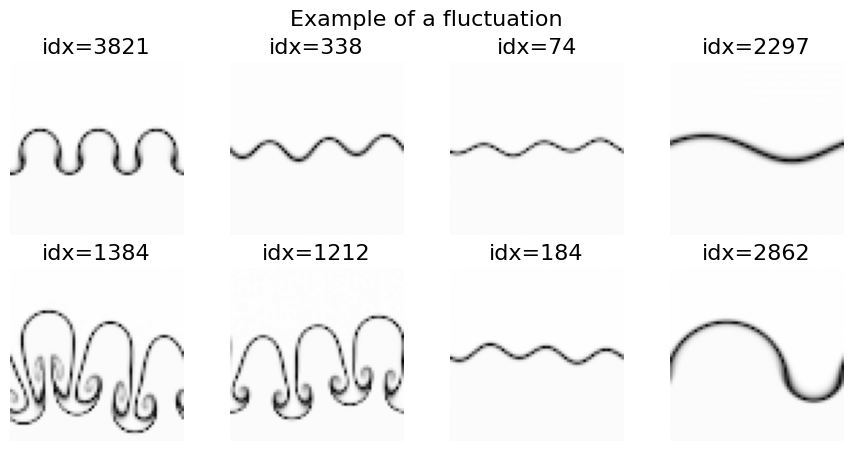

/tmp/ipykernel_8570/1944558796.py:5: RuntimeWarning: divide by zero encountered in log
  show_grid(abs(np.log(fluctuation_spectrum_val)), n=8, cols=4, cmap=CMAP, title="Log fluctuation spectrum")


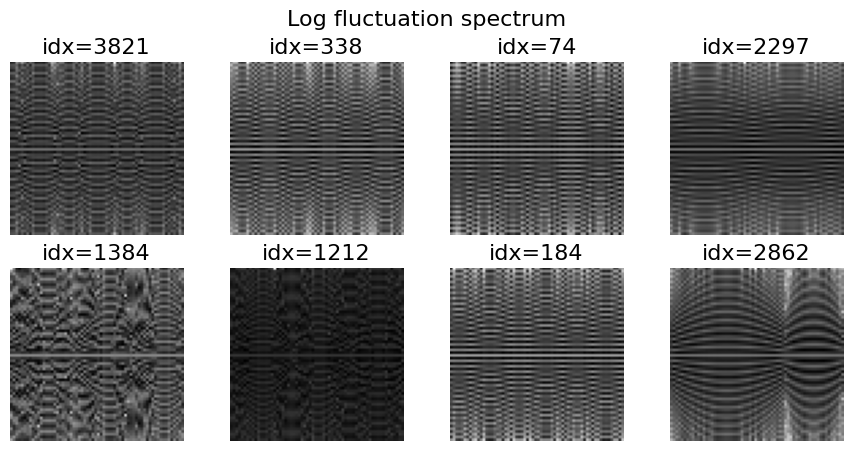

/tmp/ipykernel_8570/1944558796.py:8: RuntimeWarning: divide by zero encountered in log
  show_grid(np.log(energy_spectrum_val), n=8, cols=4, cmap=CMAP, title="Log fluctuation energy spectrum")


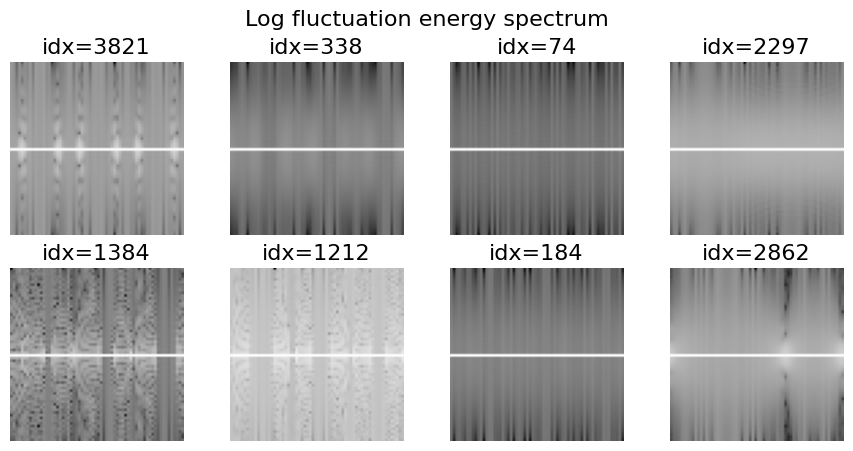

(<Figure size 880x440 with 8 Axes>,
 array([3821,  338,   74, 2297, 1384, 1212,  184, 2862]))

In [8]:
fluctuation_val = np.abs(val_stats - val_stats.mean())
show_grid(fluctuation_val, n=8, cols=4, cmap=CMAP, title="Example of a fluctuation")

fluctuation_spectrum_val = np.fft.fftshift(np.fft.fft(fluctuation_val, axis=1), axes=1)
show_grid(abs(np.log(fluctuation_spectrum_val)), n=8, cols=4, cmap=CMAP, title="Log fluctuation spectrum")

energy_spectrum_val = np.abs(fluctuation_spectrum_val) ** 2
show_grid(np.log(energy_spectrum_val), n=8, cols=4, cmap=CMAP, title="Log fluctuation energy spectrum")

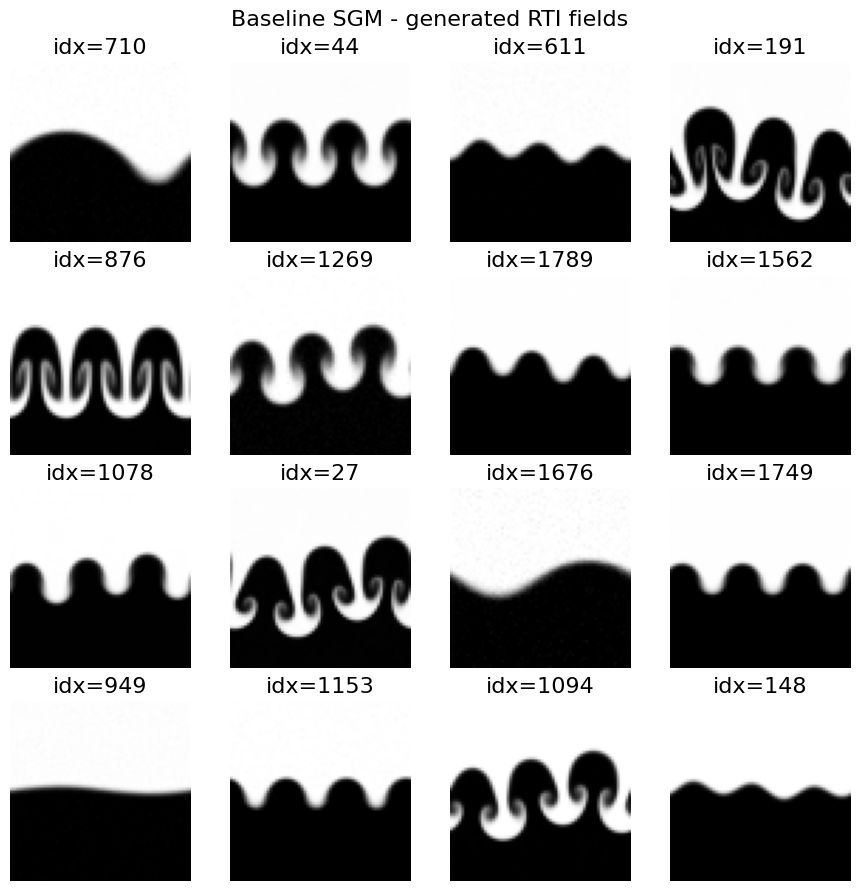

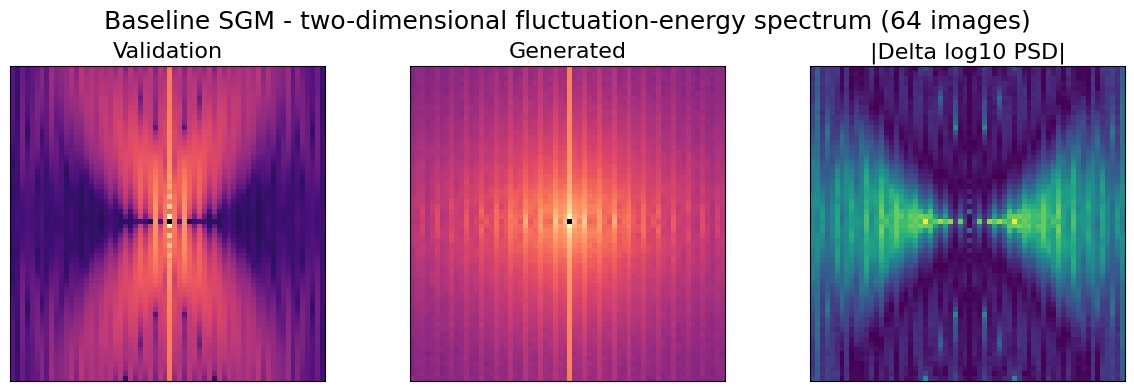

Baseline report diagnostics on 64 images
Density: {'mu_distance': 0.006245025831793444, 'sigma_distance': 0.005242250772794527, 'mu_profile': array([0.99332386, 0.99291651, 0.99234163, 0.99279874, 0.99242575,
       0.9921462 , 0.9917246 , 0.98995807, 0.98818599, 0.98624304,
       0.98327303, 0.98001054, 0.97592162, 0.97007713, 0.96220516,
       0.95120627, 0.93760075, 0.92205983, 0.90318951, 0.88137414,
       0.85624351, 0.82756021, 0.79564361, 0.76050153, 0.7234532 ,
       0.68448874, 0.6450756 , 0.60653856, 0.56813795, 0.52681481,
       0.47787239, 0.41847954, 0.36083998, 0.31220097, 0.2820404 ,
       0.26408806, 0.25289009, 0.24479535, 0.2374766 , 0.23013094,
       0.22212309, 0.21349752, 0.20446713, 0.19431625, 0.18295075,
       0.17136408, 0.15917262, 0.14647311, 0.13349368, 0.12075319,
       0.10739911, 0.09364807, 0.08008602, 0.06661112, 0.05490633,
       0.04584017, 0.03826507, 0.03128716, 0.0244949 , 0.01732784,
       0.01065268, 0.006467  , 0.00521886, 0.0050185 ]

In [9]:
if SAVE_REPORT_FIGURES:
    report_n = min(64, len(val_stats), len(baseline_stats["generated"]))
    fig, _ = show_grid(
        baseline["generated"],
        n=16,
        cols=4,
        seed=16,
        cmap=CMAP,
        title="Baseline SGM - generated RTI fields",
    )
    save_figure(fig, REPORT_FIGURE_DIR / "baseline_sgm_grid.png")
    plt.close(fig)

    fig, baseline_spectral_metrics = plot_spectral_energy(
        val_stats[:report_n],
        baseline_stats["generated"][:report_n],
        title="Baseline SGM - two-dimensional fluctuation-energy spectrum (64 images)",
    )
    save_figure(fig, REPORT_FIGURE_DIR / "baseline_sgm_spectrum.png")
    plt.close(fig)

    print("Baseline report diagnostics on", report_n, "images")
    print("Density:", density_stats["generated"])
    print("Fluctuation energy:", energy_stats["generated"])

## Cascade WSGM

Changer `CASCADE_KEY` dans la cellule de parametres pour alterner entre `generated_coarse` et `reference_coarse`.

In [10]:
cascade = load_cascade_data(cascade_cfg)
real_coeffs = cascade["real_coeffs"]
generated_coeffs = cascade["generated_coeffs"]
reconstructed_ca = cascade["reconstructed_ca"]
final_real_images = cascade["final_real_images"]
final_generated_images = cascade["final_generated_images"]

summary = {
    **{f"real coeffs j{level}": real_coeffs[level] for level in cascade_cfg.cascade_levels},
    **{f"generated coeffs j{level}": generated_coeffs[level] for level in cascade_cfg.cascade_levels},
    f"initial cA{cascade_cfg.coarse_level}": generated_coeffs[cascade_cfg.coarse_key],
    **{f"reconstructed cA{level}": reconstructed_ca[level] for level in sorted(reconstructed_ca, reverse=True)},
    "final real images": final_real_images,
    "final generated images": final_generated_images,
}
print_dataset_summaries(summary)

real coeffs j2               shape=(4500, 4, 16, 16)  dtype=torch.float32 min=  -1.754 max=   4.000 mean=   0.512 std=   1.283
real coeffs j1               shape=(4500, 4, 32, 32)  dtype=torch.float32 min=  -0.793 max=   2.000 mean=   0.252 std=   0.645
generated coeffs j2          shape=(2048, 4, 16, 16)  dtype=torch.float32 min=  -1.892 max=   3.824 mean=   0.506 std=   1.222
generated coeffs j1          shape=(2048, 4, 32, 32)  dtype=torch.float32 min=  -0.858 max=   2.471 mean=   0.251 std=   0.616
initial cA2                  shape=(2048, 1, 16, 16)  dtype=torch.float32 min=   0.155 max=   3.824 mean=   1.973 std=   1.714
reconstructed cA1            shape=(2048, 1, 32, 32)  dtype=torch.float32 min=  -0.429 max=   2.471 mean=   0.986 std=   0.881
final real images            shape=(4500, 64, 64)     dtype=torch.float32 min=  -0.000 max=   1.000 mean=   0.497 std=   0.483
final generated images       shape=(2048, 1, 64, 64)  dtype=torch.float32 min=  -0.258 max=   1.262 mean=   0.4

In [11]:
if RUN_PHYFID:
    stage_scores = compute_cascade_stage_phyfid(cascade_cfg, cascade, device=DEVICE)
    print_phyfid_stage_table(stage_scores)

Etape image                       n encodeur                           ref vs ref   ref vs generated
coarse cA2                     1000 coarse_cA2_phyfid_encoder.pt           0.0000             0.0001
w2 -> cA1 projete 64           1000 64phyfid_encoder.pt                    0.5001             2.8304
w1 -> image finale             1000 64phyfid_encoder.pt                    0.6658             3.0953


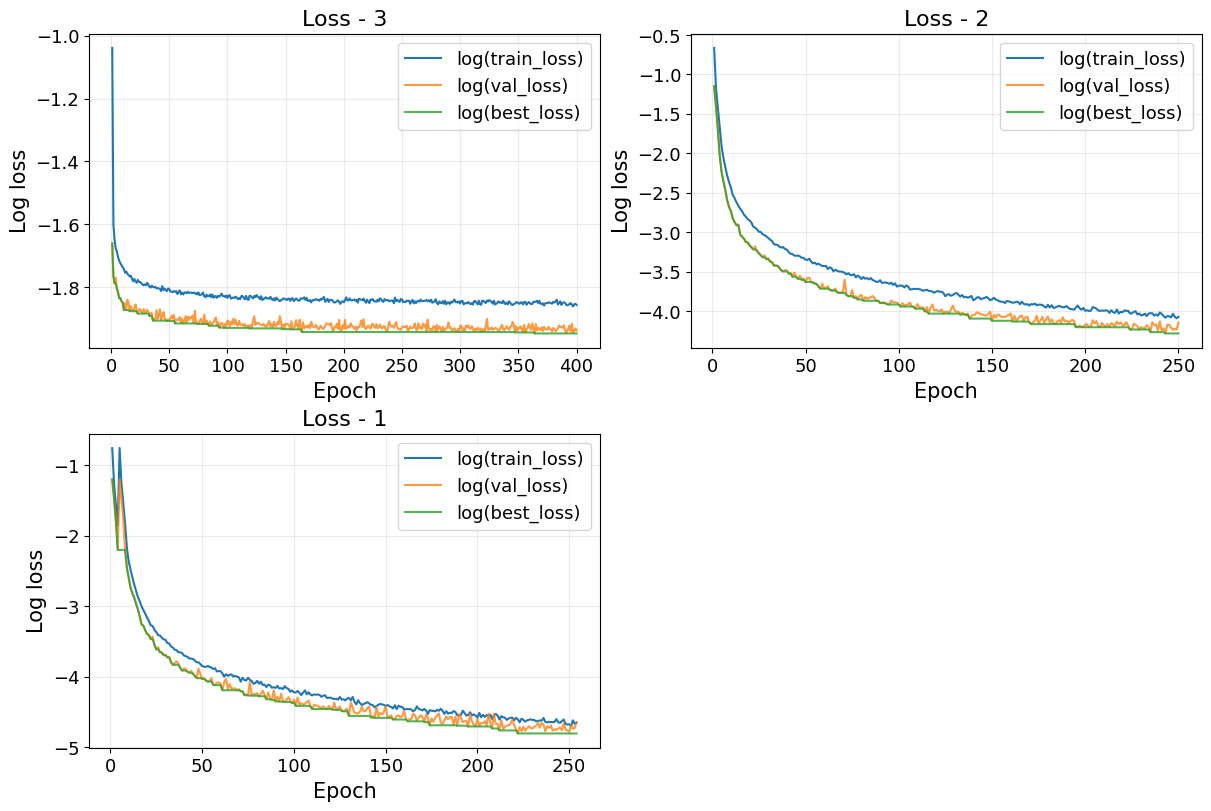

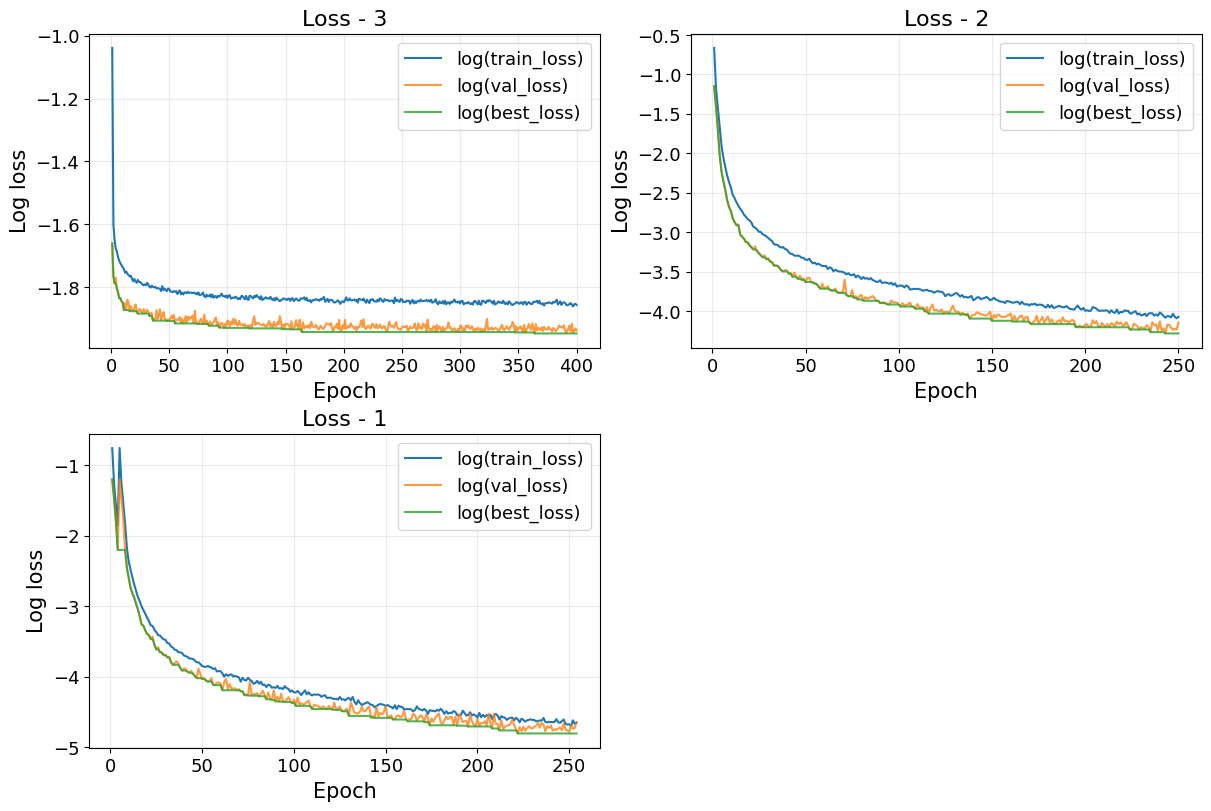

In [12]:
plot_loss_curves(
    cascade_cfg.loss_paths,
    save=SAVE_REPORT_FIGURES,
    save_path=cascade_cfg.output_dir / "loss_curves.png",
)

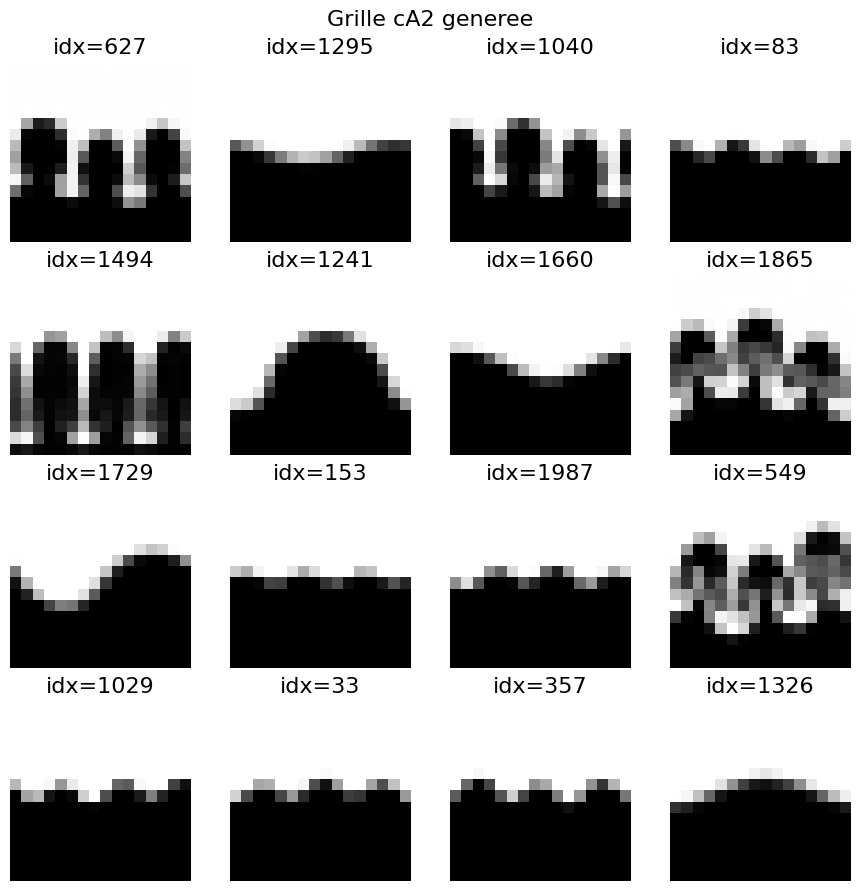

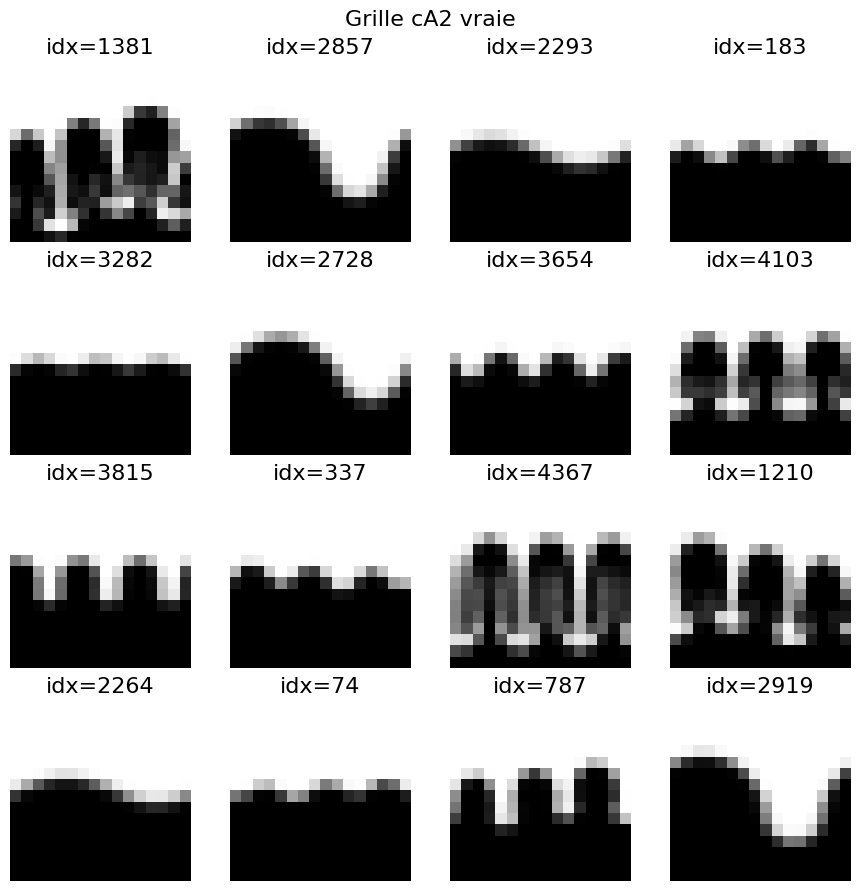

(<Figure size 880x880 with 16 Axes>,
 array([1381, 2857, 2293,  183, 3282, 2728, 3654, 4103, 3815,  337, 4367,
        1210, 2264,   74,  787, 2919]))

In [13]:
show_grid(
    generated_coeffs[cascade_cfg.coarse_key],
    n=16,
    cols=4,
    seed=SEED,
    cmap=CMAP,
    title=f"Grille cA{cascade_cfg.coarse_level} generee",
)
show_grid(
    real_coeffs[cascade_cfg.coarse_level][:, 0:1],
    n=16,
    cols=4,
    seed=SEED,
    cmap=CMAP,
    title=f"Grille cA{cascade_cfg.coarse_level} vraie",
)

/tmp/ipykernel_8570/2974214011.py:3: RuntimeWarning: invalid value encountered in log
  np.log(real_coeffs[level] + 1e-8),
/tmp/ipykernel_8570/2974214011.py:3: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  np.log(real_coeffs[level] + 1e-8),
/tmp/ipykernel_8570/2974214011.py:4: RuntimeWarning: invalid value encountered in log
  np.log(generated_coeffs[level] + 1e-8),
/tmp/ipykernel_8570/2974214011.py:4: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  np.log(generated_coeffs[level] + 1e-8),


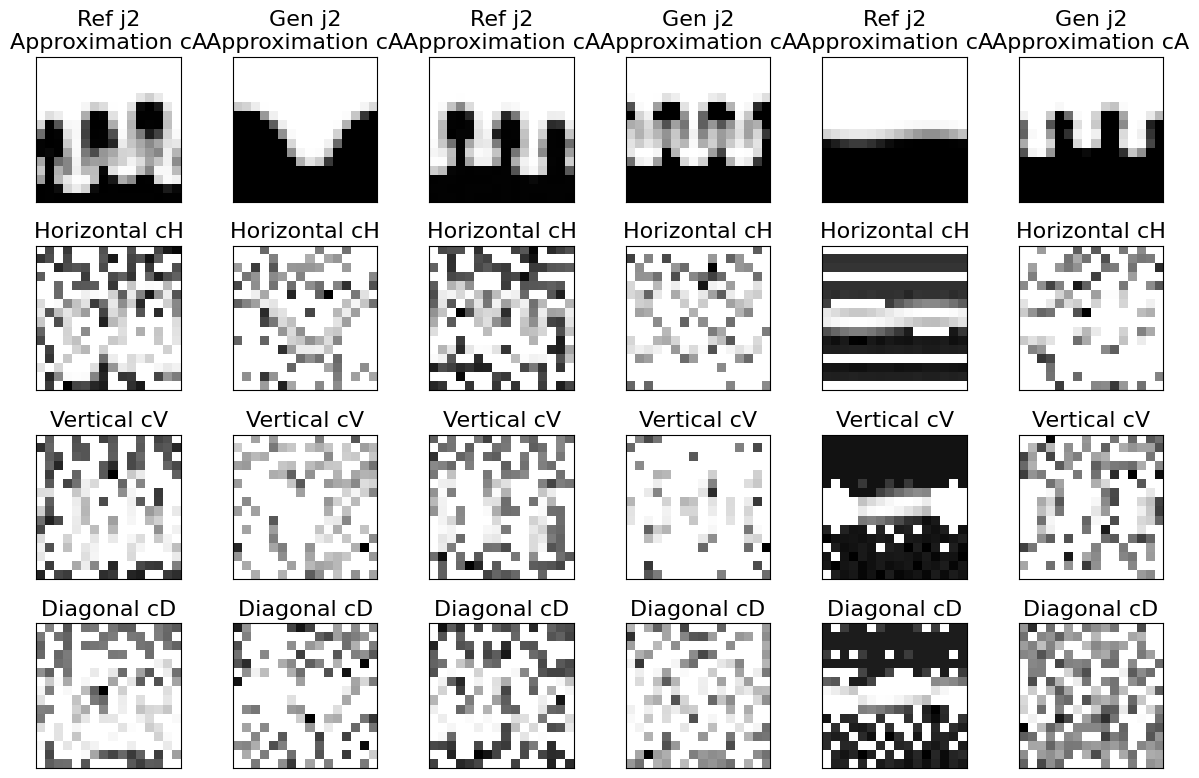

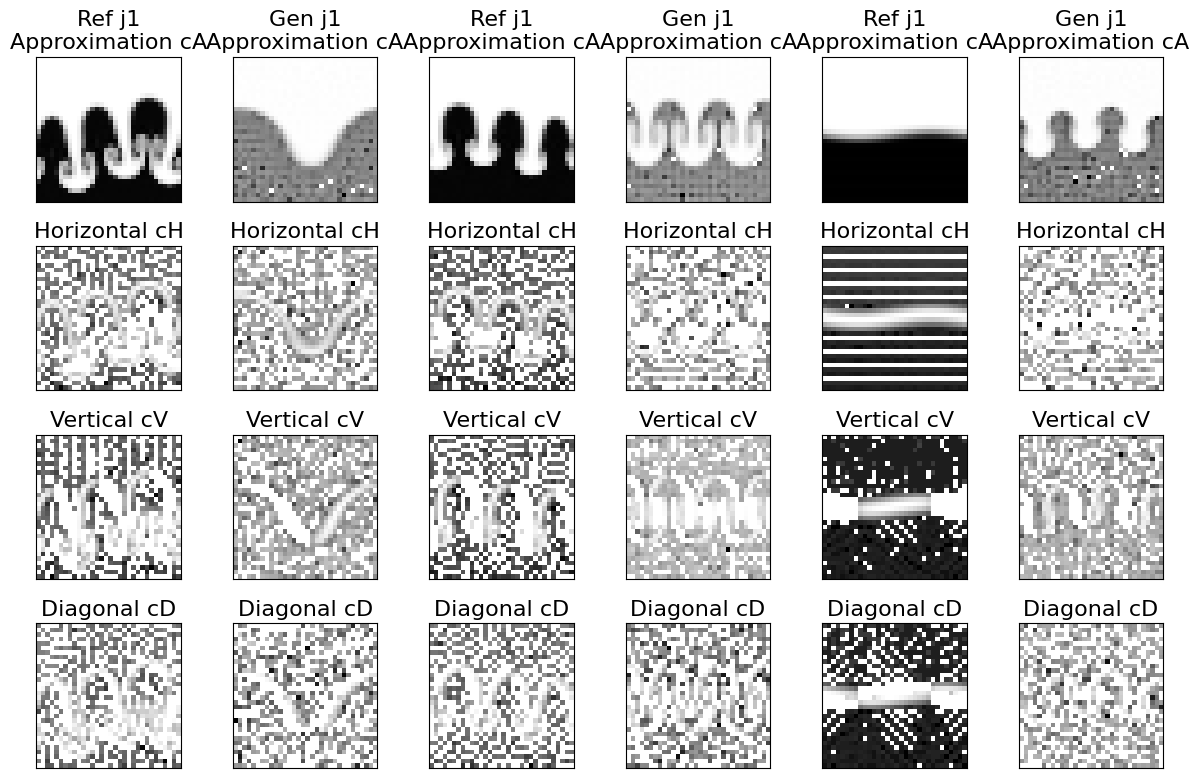

In [14]:
for level in cascade_cfg.cascade_levels:
    plot_wavelet_level_comparison(
        np.log(real_coeffs[level] + 1e-8),
        np.log(generated_coeffs[level] + 1e-8),
        level=level,
        n_examples=3,
        seed=SEED,
        cmap=CMAP,
    )

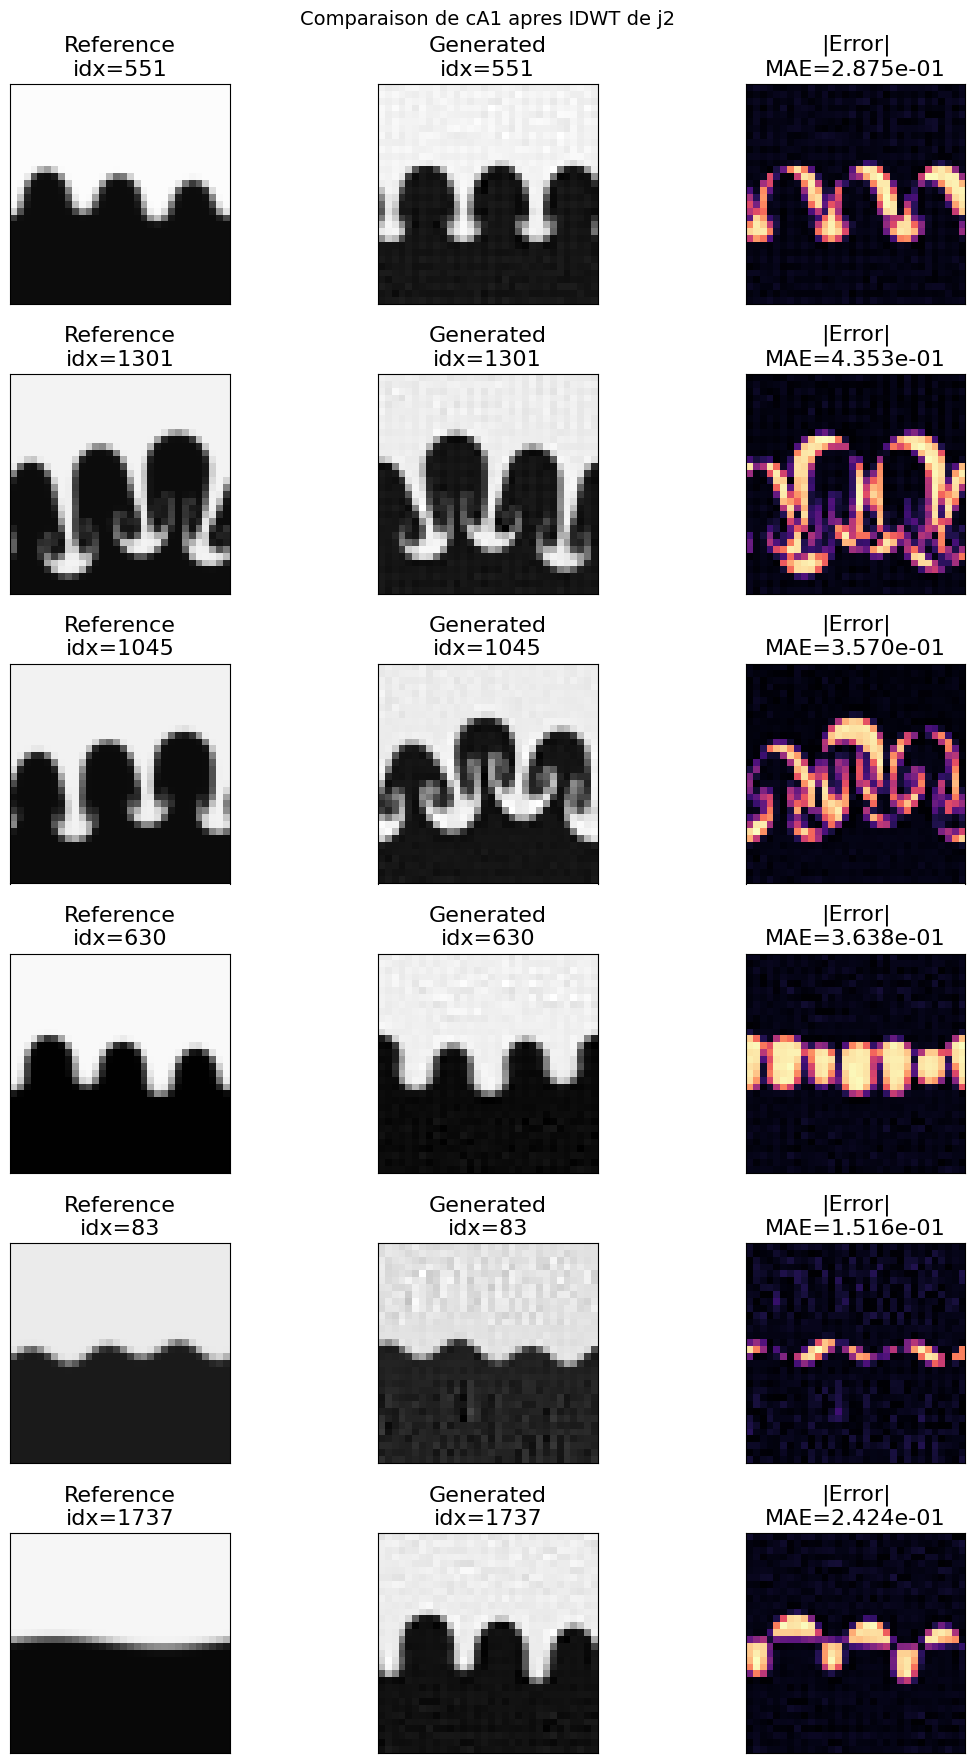

In [15]:
for level in sorted(reconstructed_ca, reverse=True):
    plot_single_channel_comparison(
        real_coeffs[level][:, 0:1],
        reconstructed_ca[level],
        title=f"Comparaison de cA{level} apres IDWT de j{level + 1}",
        n_examples=6,
        seed=SEED,
        cmap=CMAP,
    )

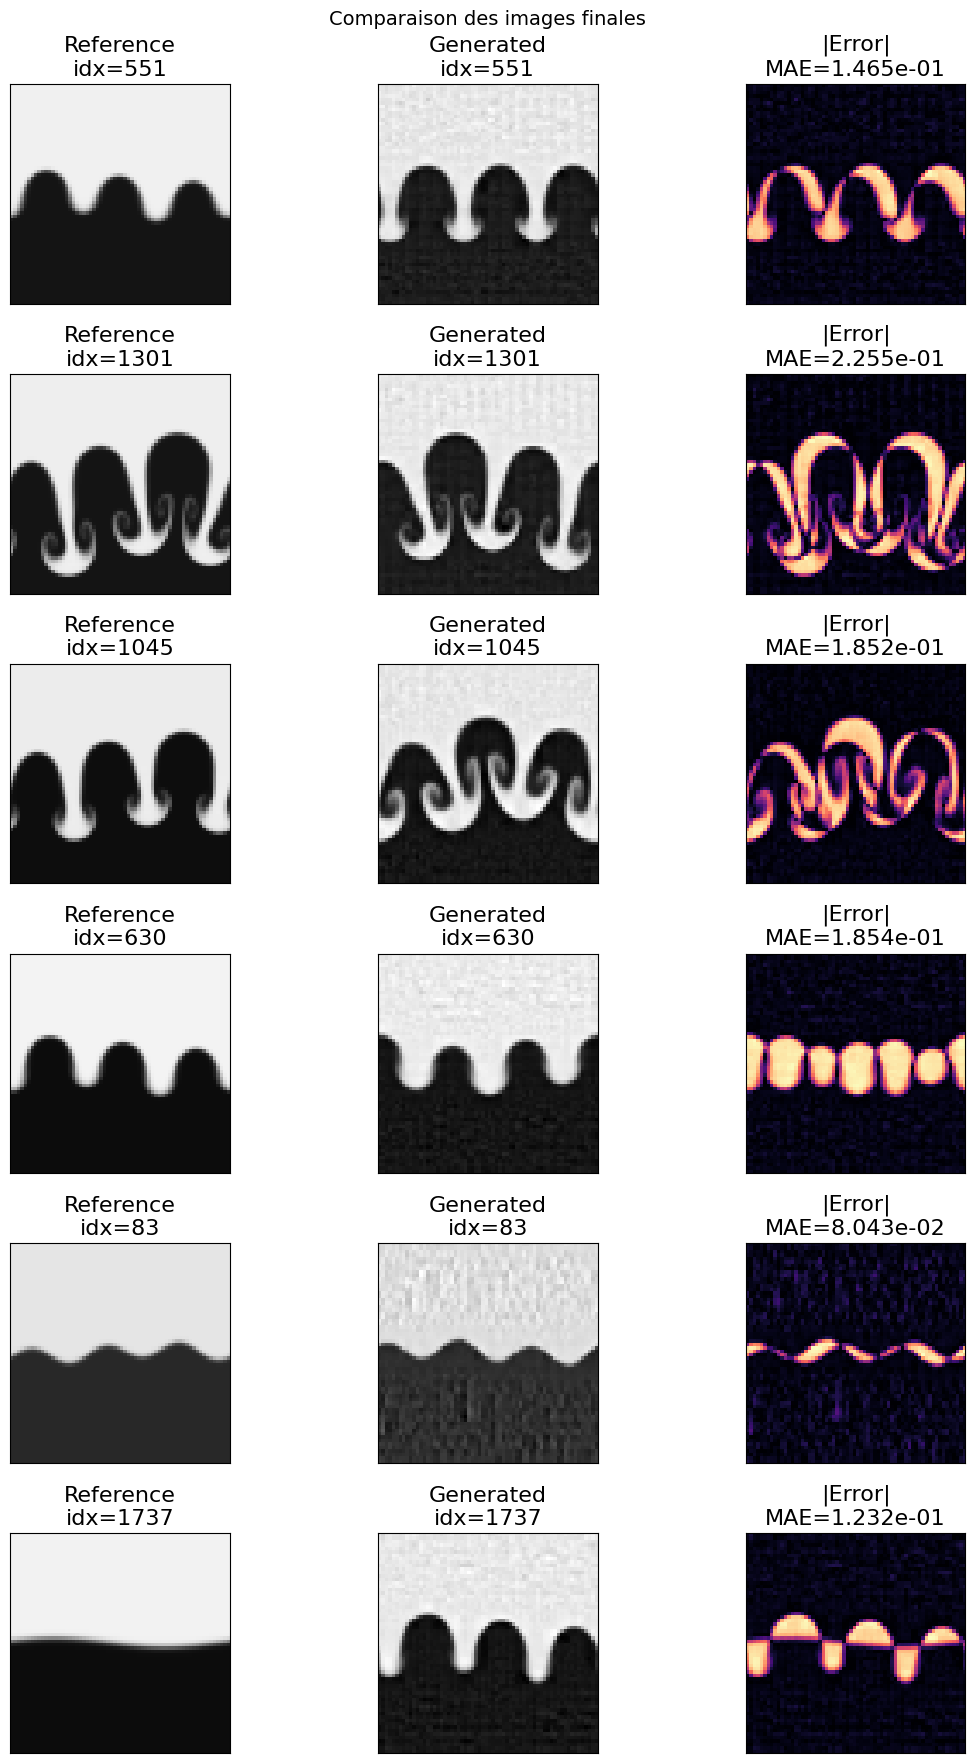

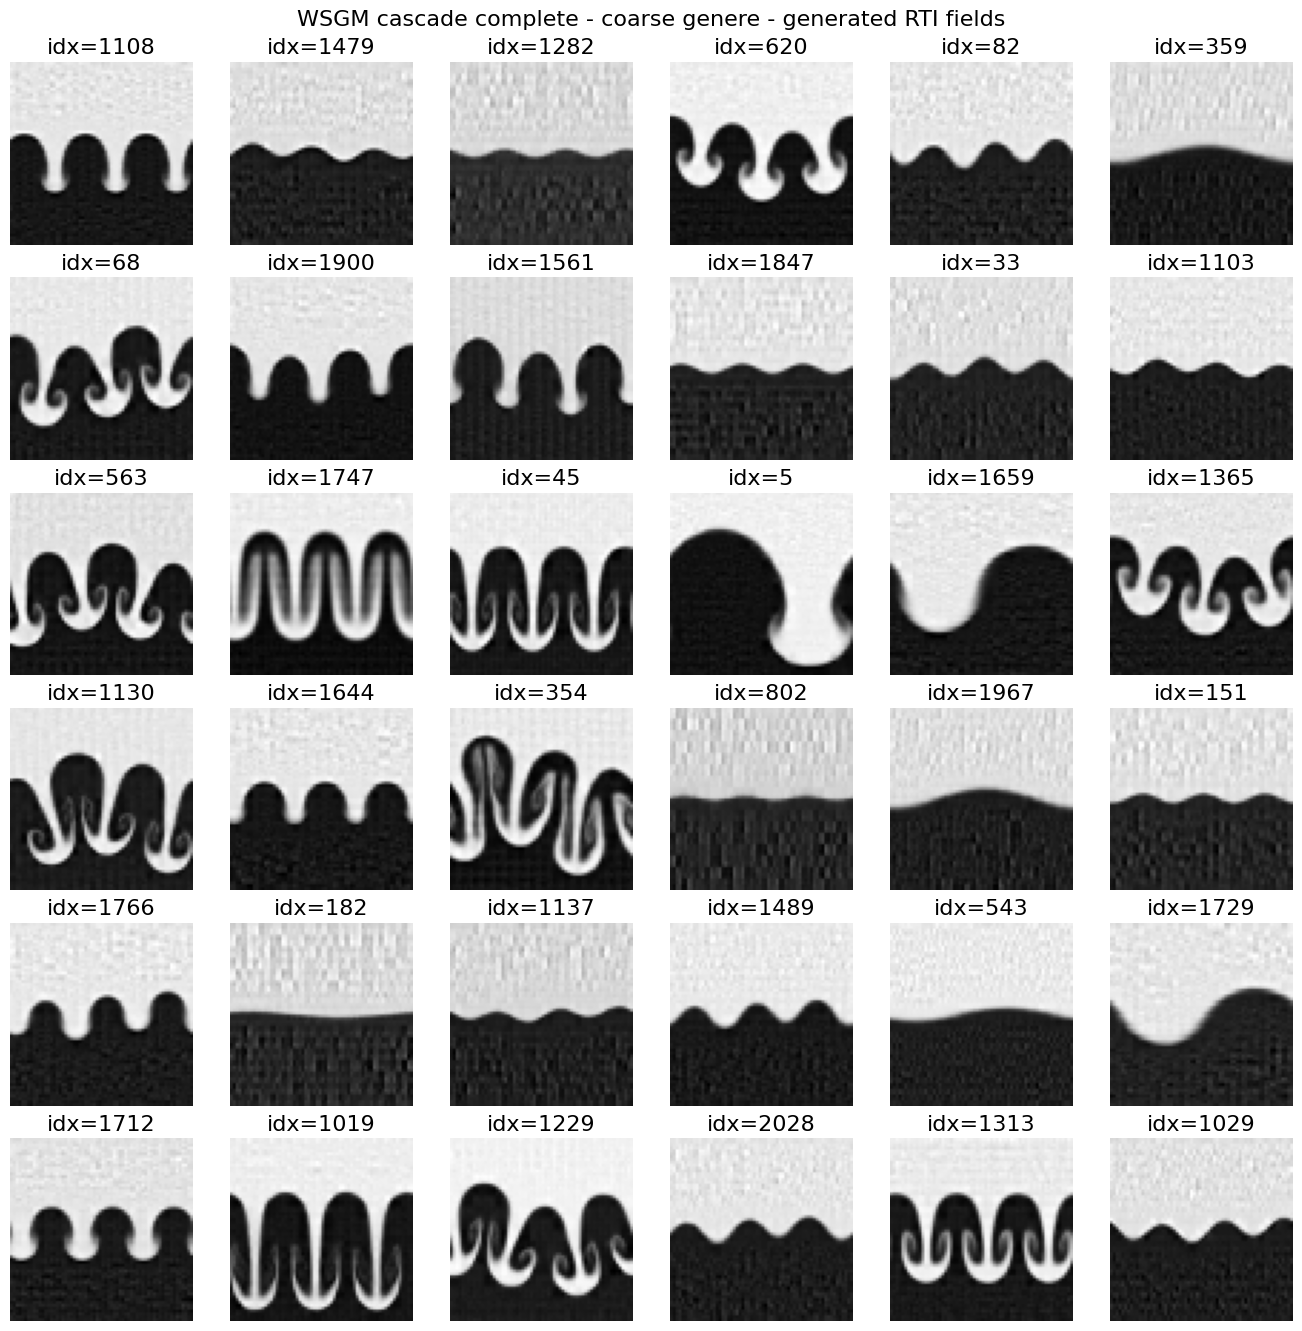

(<Figure size 1320x1320 with 36 Axes>,
 array([1108, 1479, 1282,  620,   82,  359,   68, 1900, 1561, 1847,   33,
        1103,  563, 1747,   45,    5, 1659, 1365, 1130, 1644,  354,  802,
        1967,  151, 1766,  182, 1137, 1489,  543, 1729, 1712, 1019, 1229,
        2028, 1313, 1029]))

In [16]:
plot_single_channel_comparison(
    final_real_images,
    final_generated_images,
    title="Final-image comparison",
    n_examples=6,
    seed=SEED,
    cmap=CMAP,
)
show_grid(
    final_generated_images,
    n=36 if CASCADE_KEY == "generated_coarse" else 16,
    cols=6 if CASCADE_KEY == "generated_coarse" else 4,
    cmap=CMAP,
    seed=SEED,
    title=f"{cascade_report_label} - generated RTI fields",
    save=SAVE_REPORT_FIGURES and CASCADE_KEY == "reference_coarse",
    save_path=REPORT_FIGURE_DIR / "reference_WSGM.png",
)

Erreur coarse cA2: MAE=0.67446, RMSE=1.23170
WSGM cascade complete - coarse genere: n=1000 | PhyFID(ref/ref)=0.66575 | PhyFID(ref/gen)=3.09526 | spectral L1=0.32394 | log-spectrum RMSE=0.65716 | energy ratio=0.20861


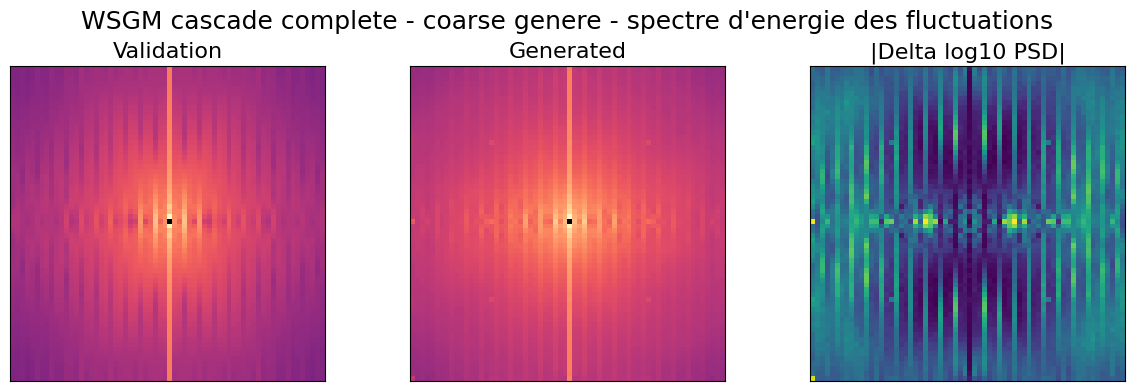

In [17]:
if RUN_PHYFID:
    cascade_metrics = compare_result_metrics(
        final_real_images,
        final_generated_images,
        cascade_cfg.phyfid_encoder_64,
        max_images=cascade_cfg.phyfid_max_images,
        batch_size=cascade_cfg.phyfid_batch_size,
        device=DEVICE,
    )
    coarse_reference = real_coeffs[cascade_cfg.coarse_level][:, :1]
    coarse_error = (
        generated_coeffs[cascade_cfg.coarse_key][:len(coarse_reference)]
        - coarse_reference[:len(generated_coeffs[cascade_cfg.coarse_key])]
    ).abs()
    print(f"Erreur coarse cA{cascade_cfg.coarse_level}: MAE={coarse_error.mean():.5f}, RMSE={coarse_error.square().mean().sqrt():.5f}")
    print_result_metrics(cascade_cfg.name, cascade_metrics)
    plot_spectral_energy(
        final_real_images[:cascade_metrics["n"]],
        final_generated_images[:cascade_metrics["n"]],
        title=f"{cascade_report_label} - fluctuation-energy spectrum",
    )

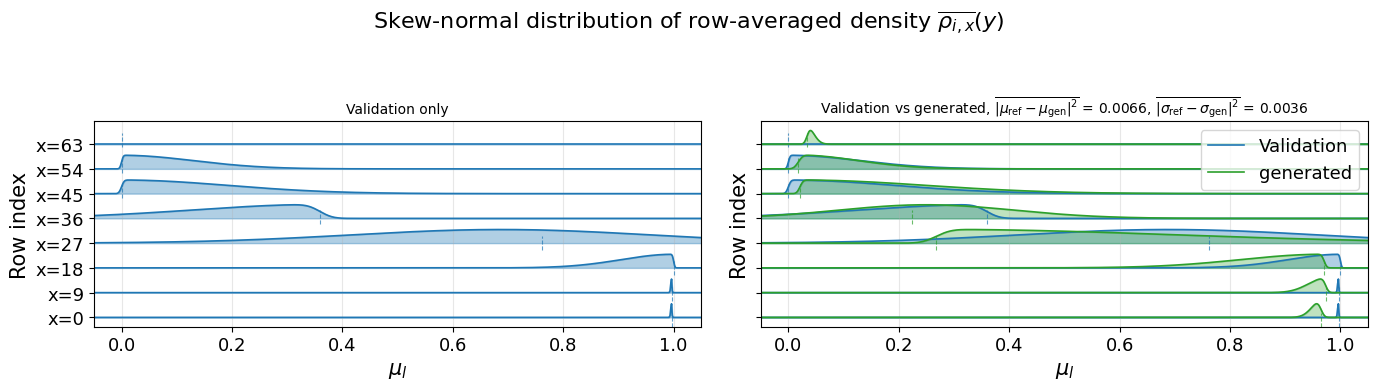

In [18]:
generated_stats = normalize_01(final_generated_images)
validation_stats = normalize_01(load_baseline_data(baseline_cfg)["validation"])

fig, wsgm_density_stats = plot_density_joyplots(
    validation_stats,
    {"generated": generated_stats},
    n_curves=8,
    colors={"generated": cascade_joyplot_color},
    title_labels={"generated": cascade_joyplot_label},
    legend_labels={"generated": cascade_joyplot_label},
    save_path=REPORT_FIGURE_DIR / ("WSGM_ref_joyplot.png" if CASCADE_KEY == "reference_coarse" else "WSGM_generated_joyplot.png") if SAVE_REPORT_FIGURES else None,
)

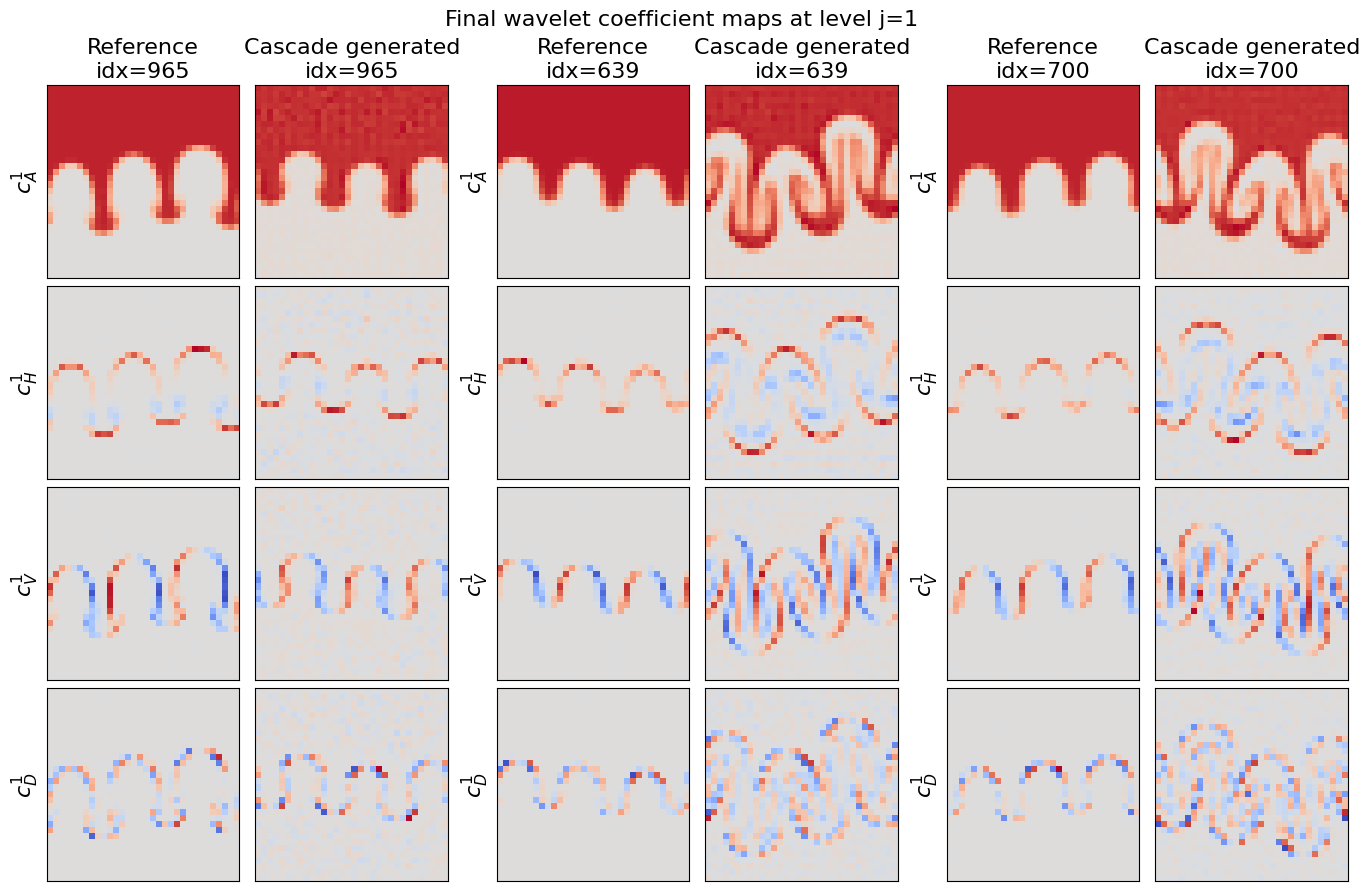

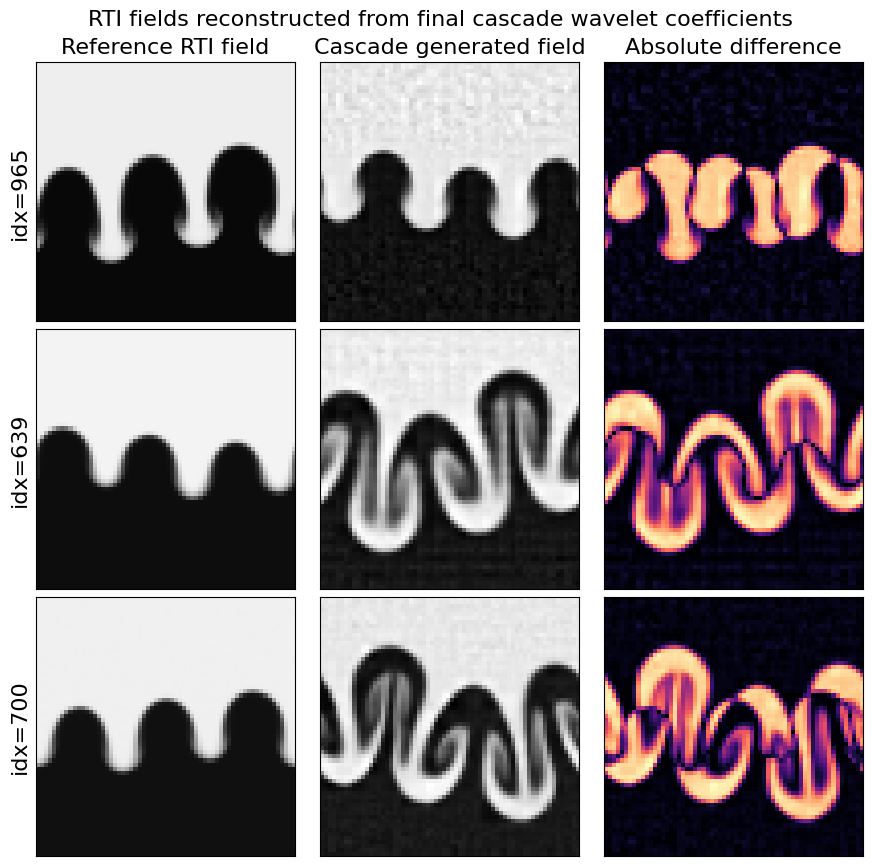

Saved:
/home/chapuissamuel/Documents/code/RT-Diffusion/doc/BDRPReportTemplate/figures/ch5/wavelet_cascade_coefficients_comparison.png
/home/chapuissamuel/Documents/code/RT-Diffusion/doc/BDRPReportTemplate/figures/ch5/wavelet_cascade_reconstruction_comparison.png


In [19]:
if SAVE_REPORT_FIGURES:
    coeff_path, rec_path = plot_wavelet_report_figures(
        real_coeffs[1],
        generated_coeffs[1],
        final_generated_images,
        indices=[965, 639, 700],
        output_dir=REPORT_FIGURE_DIR,
        coefficient_filename="wavelet_cascade_coefficients_comparison.png" if CASCADE_KEY == "generated_coarse" else "wsgm_reference_coarse_coefficients_comparison.png",
        reconstruction_filename="wavelet_cascade_reconstruction_comparison.png" if CASCADE_KEY == "generated_coarse" else "wsgm_reference_coarse_reconstruction_comparison.png",
        wavelet=cascade_cfg.wavelet,
        mode=cascade_cfg.mode,
    )
    print("Saved:")
    print(coeff_path)
    print(rec_path)

## Comparaison rapide des deux cascades

Cette cellule charge les deux jeux de sorties et compare uniquement les diagnostics legers; elle evite PhyFID par defaut.

In [20]:
rows = []
for key, cfg in cascade_cfgs.items():
    data = load_cascade_data(cfg)
    ref = normalize_01(data["final_real_images"])
    gen = normalize_01(data["final_generated_images"])
    mu_dist, *_ = line_metric(ref, gen, metric_name="mu")
    sigma_dist, *_ = line_metric(ref, gen, metric_name="sigma")
    rows.append((key, cfg.name, mu_dist, sigma_dist, len(gen)))

print(f"{'key':<18} {'n':>6} {'mu dist':>12} {'sigma dist':>12}  name")
for key, name, mu_dist, sigma_dist, n in rows:
    print(f"{key:<18} {n:>6} {mu_dist:>12.5f} {sigma_dist:>12.5f}  {name}")

key                     n      mu dist   sigma dist  name
generated_coarse     2048      0.00670      0.00347  WSGM cascade complete - coarse genere
reference_coarse     2048      0.00395      0.00303  WSGM cascade - coarse reel
